In [ ]:
from google.colab import files

uploaded = files.upload()

Saving diabetes.csv to diabetes.csv


In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score

In [ ]:
df = pd.read_csv('diabetes.csv')

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
df.info()
df.describe()
df.shape


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


(768, 9)

In [ ]:
cols = ['Glucose',
        'BloodPressure',
        'SkinThickness',
        'Insulin',
        'BMI']

df[cols] = df[cols].replace(0, np.nan)

In [ ]:
df.fillna(df.median(), inplace=True)

df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [ ]:
X = df.drop('Outcome', axis=1)

y = df['Outcome']

In [ ]:
scaler = StandardScaler()

X = scaler.fit_transform(X)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
print(X_train.shape)
print(X_test.shape)

(614, 8)
(154, 8)


In [ ]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

In [ ]:
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
y_pred = rf.predict(X_test)

In [ ]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[78 21]
 [19 36]]


In [ ]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy :", round(accuracy,4))
print("Precision:", round(precision,4))
print("Recall   :", round(recall,4))
print("F1 Score :", round(f1,4))

Accuracy : 0.7403
Precision: 0.6316
Recall   : 0.6545
F1 Score : 0.6429


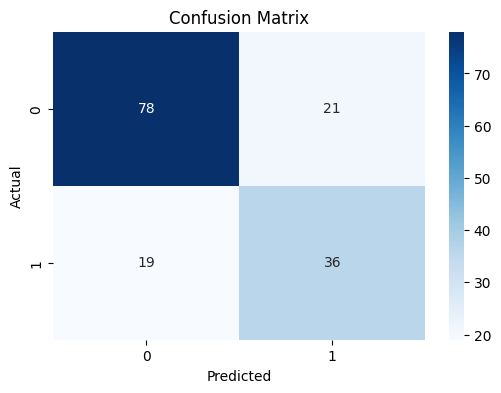

In [ ]:
plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [ ]:
y_prob = rf.predict_proba(X_test)[:,1]

In [ ]:
fpr, tpr, threshold = roc_curve(
    y_test,
    y_prob
)

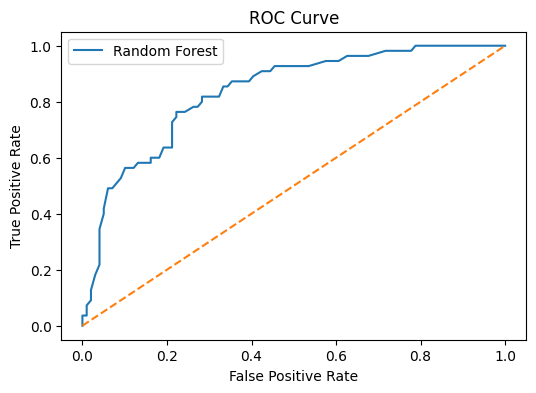

In [ ]:
plt.figure(figsize=(6,4))

plt.plot(fpr,tpr,
         label='Random Forest')

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

In [ ]:
pregnancies = int(input("Enter Pregnancies: "))
glucose = float(input("Enter Glucose: "))
blood_pressure = float(input("Enter Blood Pressure: "))
skin_thickness = float(input("Enter Skin Thickness: "))
insulin = float(input("Enter Insulin: "))
bmi = float(input("Enter BMI: "))
dpf = float(input("Enter Diabetes Pedigree Function: "))
age = int(input("Enter Age: "))

new_data = [[
    pregnancies,
    glucose,
    blood_pressure,
    skin_thickness,
    insulin,
    bmi,
    dpf,
    age
]]

new_data = scaler.transform(new_data)

prediction = rf.predict(new_data)

if prediction[0] == 1:
    print("Patient is likely DIABETIC")
else:
    print("Patient is likely NON-DIABETIC")

Enter Pregnancies: 6
Enter Glucose: 148
Enter Blood Pressure: 72
Enter Skin Thickness: 35
Enter Insulin: 0
Enter BMI: 33.6
Enter Diabetes Pedigree Function: 0.627
Enter Age: 50
Patient is likely DIABETIC


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
